<a href="https://colab.research.google.com/github/nadiagul01/My-Portfolio/blob/main/24i_7815_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Accent Classification — VSAA-AC Pipeline
**Student:** Nadia Gul | **Roll:** 24i-7815  
**Dataset:** Speech Accent Archive (Kaggle)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Install Libraries

In [ ]:
!pip install -q librosa praat-parselmouth scikit-learn torch torchaudio \
    transformers statsmodels matplotlib seaborn pandas numpy tqdm soundfile \
    audiomentations \
    audiomentations
print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 25.2 MB/s eta 0:00:00
✅ Done!


## Imports

In [ ]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import librosa, soundfile as sf
import parselmouth
from parselmouth.praat import call
import audiomentations
from transformers import Wav2Vec2Model, Wav2Vec2Processor

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Function
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, \
                            confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_SR = 16000
print(f'✅ Imports done. Device: {DEVICE}')

✅ Imports done. Device: cuda


##  Dataset Setup

In [ ]:
# ══════════════════════════════════════════════════════════════════
KAGGLE_DIR = Path('/content/drive/MyDrive/archive')
# ══════════════════════════════════════════════════════════════════

RECORDINGS_DIR = KAGGLE_DIR / 'recordings' / 'recordings'
CSV_PATH       = KAGGLE_DIR / 'speakers_all.csv'
WAV_DIR        = Path('data_wav')
FEAT_DIR       = Path('features')
RESULT_DIR     = Path('results')

for d in [WAV_DIR, FEAT_DIR, RESULT_DIR]:
    d.mkdir(exist_ok=True)
for acc in ['indian','american','british']:
    (WAV_DIR / acc).mkdir(exist_ok=True)

df_csv = pd.read_csv(CSV_PATH)
print('CSV columns:', df_csv.columns.tolist())
print(f'Total speakers in CSV: {len(df_csv)}')
print(df_csv.head(3))

CSV columns: ['age', 'age_onset', 'birthplace', 'filename', 'native_language', 'sex', 'speakerid', 'country', 'file_missing?', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
Total speakers in CSV: 2172
    age  age_onset              birthplace  filename native_language   sex  \
0  24.0       12.0         koussi, senegal   balanta         balanta  male   
1  18.0       10.0          buea, cameroon  cameroon        cameroon  male   
2  48.0        8.0  hong, adamawa, nigeria  fulfulde        fulfulde  male   

   speakerid   country  file_missing?  Unnamed: 9  Unnamed: 10 Unnamed: 11  
0        788   senegal           True         NaN          NaN         NaN  
1       1953  cameroon           True         NaN          NaN         NaN  
2       1037   nigeria           True         NaN          NaN         NaN  


## **Filter Indian / American / British from the CSV**


In [ ]:
# ── Speaker selection rules ───────────────────────────────────────

INDIAN_LANGS = ['hindi','telugu','gujarati','punjabi','bengali',
                'marathi','tamil','kannada','malayalam']

# American English speakers:

df_indian   = df_csv[df_csv['native_language'].isin(INDIAN_LANGS)].copy()
df_american = df_csv[
    (df_csv['native_language'] == 'english') &
    (df_csv['country'].str.lower().str.contains('usa|united states', na=False))
].copy()
df_british  = df_csv[
    (df_csv['native_language'] == 'english') &
    (df_csv['country'].str.lower().str.contains('england|uk|united kingdom', na=False))
].copy()

# Minimum 20 per class lena hai — available count dekho
print(f'Indian speakers available  : {len(df_indian)}')
print(f'American speakers available: {len(df_american)}')
print(f'British speakers available : {len(df_british)}')

# 30 each lo (zyada hain toh)
N_PER_CLASS = 500  # Increased from 80 to 500 for more data
df_indian   = df_indian.head(N_PER_CLASS)
df_american = df_american.head(N_PER_CLASS)
df_british  = df_british.head(N_PER_CLASS)

print(f'\nUsing {len(df_indian)} Indian | {len(df_american)} American | {len(df_british)} British speakers')

Indian speakers available  : 70
American speakers available: 373
British speakers available : 65

Using 70 Indian | 373 American | 65 British speakers


## Audio Files Copy + Convert to WAV 16kHz

In [ ]:
# ──Convert MP3 → WAV 16kHz  ─────────────────────────────────
metadata = []

def process_group(df_group, accent_label):
    count = 0
    for _, row in tqdm(df_group.iterrows(), total=len(df_group), desc=accent_label):

        fname = str(row.get('filename_sound', row.get('filename', ''))).strip()
        if not fname.endswith('.mp3'):
            fname = fname + '.mp3'

        mp3_path = RECORDINGS_DIR / fname
        if not mp3_path.exists():
            # Try without extension
            mp3_path = RECORDINGS_DIR / (fname.replace('.mp3','') + '.mp3')
        if not mp3_path.exists():
            continue

        out_path = WAV_DIR / accent_label / f'spk{count:03d}.wav'
        if not out_path.exists():
            try:
                y, sr = librosa.load(str(mp3_path), sr=TARGET_SR, mono=True)
                sf.write(str(out_path), y, TARGET_SR)
            except Exception as e:
                print(f'Error {mp3_path.name}: {e}')
                continue

        metadata.append({
            'path'      : str(out_path),
            'accent'    : accent_label,
            'speaker_id': f'{accent_label}_spk{count:03d}'
        })
        count += 1

process_group(df_indian,   'indian')
process_group(df_american, 'american')
process_group(df_british,  'british')

df_meta = pd.DataFrame(metadata)
df_meta.to_csv(FEAT_DIR / 'metadata.csv', index=False)

print(f'\n✅ Total utterances processed: {len(df_meta)}')
print(df_meta['accent'].value_counts())

british: 100%|██████████| 65/65 [00:22<00:00,  2.85it/s]


✅ Total utterances processed: 508
accent
american    373
indian       70
british      65
Name: count, dtype: int64


In [ ]:
import os

print(f"RECORDINGS_DIR: {RECORDINGS_DIR}")

# Check if RECORDINGS_DIR exists
if not RECORDINGS_DIR.exists():
    print(f"❌ Error: The directory '{RECORDINGS_DIR}' does not exist. Please check your KAGGLE_DIR path.")
else:
    print(f"✅ Directory '{RECORDINGS_DIR}' exists.")
    # List a few files to see if anything is there
    sample_files = list(RECORDINGS_DIR.iterdir())
    if sample_files:
        print(f"Found {len(sample_files)} files/folders in RECORDINGS_DIR. First 5: {[f.name for f in sample_files[:5]]}")
    else:
        print(f"❌ Directory '{RECORDINGS_DIR}' is empty.")

    # Get a sample filename from one of the dataframes (e.g., df_indian)
    if not df_indian.empty:
        sample_csv_filename = str(df_indian.iloc[0].get('filename_sound', df_indian.iloc[0].get('filename', ''))).strip()
        if not sample_csv_filename.endswith('.mp3'):
            sample_csv_filename += '.mp3'
        sample_mp3_path = RECORDINGS_DIR / sample_csv_filename

        print(f"\nChecking for sample file '{sample_mp3_path.name}' (from df_indian first entry)...")
        if sample_mp3_path.exists():
            print(f"✅ Sample file '{sample_mp3_path.name}' found!")
        else:
            print(f"❌ Sample file '{sample_mp3_path.name}' NOT found at '{sample_mp3_path}'.")
            print("   Possible reasons: Filename mismatch, incorrect KAGGLE_DIR, or file is genuinely missing.")
    else:
        print("df_indian is empty, cannot check sample file.")

RECORDINGS_DIR: /content/drive/MyDrive/archive/recordings/recordings
✅ Directory '/content/drive/MyDrive/archive/recordings/recordings' exists.
Found 2138 files/folders in RECORDINGS_DIR. First 5: ['hindi18.mp3', 'hebrew8.mp3', 'hungarian2.mp3', 'hindi7.mp3', 'hindi15.mp3']

Checking for sample file 'bengali1.mp3' (from df_indian first entry)...
✅ Sample file 'bengali1.mp3' found!


##  MFCC Feature Extraction

In [ ]:
def extract_mfcc(wav_path):
    y, _ = librosa.load(wav_path, sr=TARGET_SR)
    mfcc   = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=13)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([mfcc, delta, delta2], axis=0).mean(axis=1)  # (39,)

X_mfcc = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='MFCC'):
    X_mfcc.append(extract_mfcc(row['path']))

X_mfcc = np.array(X_mfcc)
np.save(FEAT_DIR / 'X_mfcc.npy', X_mfcc)
print(f'✅ MFCC shape: {X_mfcc.shape}  — (speakers, 39 features)')

MFCC: 100%|██████████| 508/508 [00:19<00:00, 26.11it/s]

✅ MFCC shape: (508, 39)  — (speakers, 39 features)


## F1/F2 Vowel Formant Extraction (Parselmouth)

In [ ]:
# ── Direct formant extraction

def extract_formants_simple(wav_path):
    """
    WAV file se F1, F2 nikalo.
    Returns: [mean_F1, std_F1, mean_F2, std_F2]  → shape (4,)
    """
    try:
        snd     = parselmouth.Sound(wav_path)
        formant = snd.to_formant_burg(time_step=0.01, max_number_of_formants=5,
                                      maximum_formant=5500, window_length=0.025)
        intensity = snd.to_intensity(time_step=0.01)

        f1_vals, f2_vals = [], []
        times = np.arange(snd.xmin, snd.xmax, 0.02)  # every 20ms

        for t in times:
            try:
                inten = intensity.get_value(t)
                if inten is None or inten < 50:   # low intensity = silence, skip
                    continue
                f1 = formant.get_value_at_time(1, t)
                f2 = formant.get_value_at_time(2, t)
                # Sanity check: valid vowel formant ranges
                if (f1 and 200 < f1 < 1200 and
                    f2 and 700 < f2 < 3500):
                    f1_vals.append(f1)
                    f2_vals.append(f2)
            except:
                continue

        if len(f1_vals) < 3:
            return np.zeros(4)
        return np.array([np.mean(f1_vals), np.std(f1_vals),
                         np.mean(f2_vals), np.std(f2_vals)])
    except Exception as e:
        print(f'Formant error: {e}')
        return np.zeros(4)

X_formant = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Formants'):
    X_formant.append(extract_formants_simple(row['path']))

X_formant = np.array(X_formant)
np.save(FEAT_DIR / 'X_formant.npy', X_formant)
print(f'✅ Formant shape: {X_formant.shape}  — [mean_F1, std_F1, mean_F2, std_F2]')
print(pd.DataFrame(X_formant, columns=['μF1','σF1','μF2','σF2']).describe().round(1))

Formants: 100%|██████████| 508/508 [03:01<00:00,  2.79it/s]

✅ Formant shape: (508, 4)  — [mean_F1, std_F1, mean_F2, std_F2]
         μF1    σF1     μF2    σF2
count  508.0  508.0   508.0  508.0
mean   560.3  208.4  1801.1  418.5
std     76.8   41.0   112.7   64.4
min    383.4  107.6  1255.6  205.0
25%    512.3  178.7  1725.1  376.1
50%    554.5  207.2  1805.4  414.8
75%    598.3  241.2  1871.7  458.6
max    906.2  306.9  2240.5  707.1


## Wav2Vec Feature Extraction (Pre-trained)


In [ ]:
# ── Load Wav2Vec model ─────────────────────────────────────────────
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE)
wav2vec_model.eval()

def extract_wav2vec(wav_path):
    y, sr = librosa.load(wav_path, sr=16000)  # Wav2Vec expects 16kHz
    inputs = torch.tensor(y).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = wav2vec_model(inputs)
        # Average the hidden states across time
        return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

X_wav2vec = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Wav2Vec'):
    X_wav2vec.append(extract_wav2vec(row['path']))

X_wav2vec = np.array(X_wav2vec)
np.save(FEAT_DIR / 'X_wav2vec.npy', X_wav2vec)
print(f'✅ Wav2Vec shape: {X_wav2vec.shape}  — (speakers, 768 features)')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Wav2Vec: 100%|██████████| 508/508 [01:07<00:00,  7.55it/s]

✅ Wav2Vec shape: (508, 768)  — (speakers, 768 features)


##  Vowel Space Plot

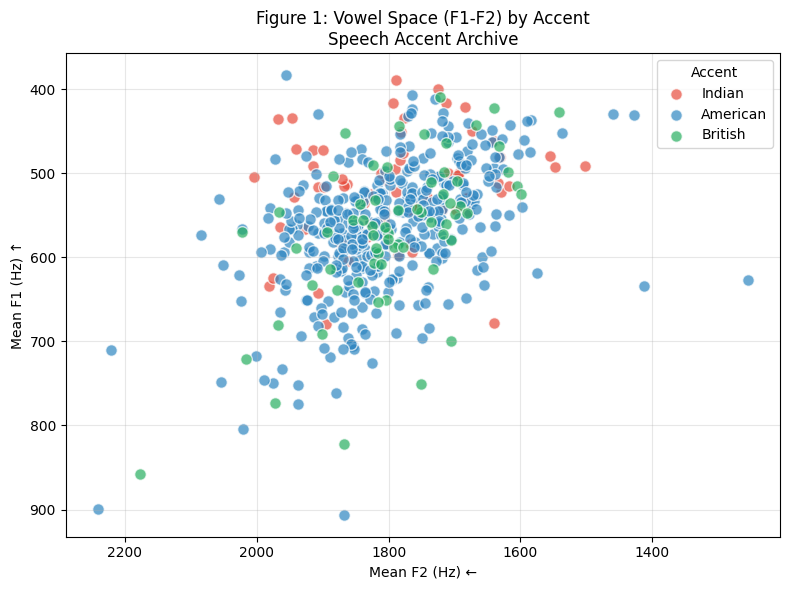

✅ Figure 1 saved.


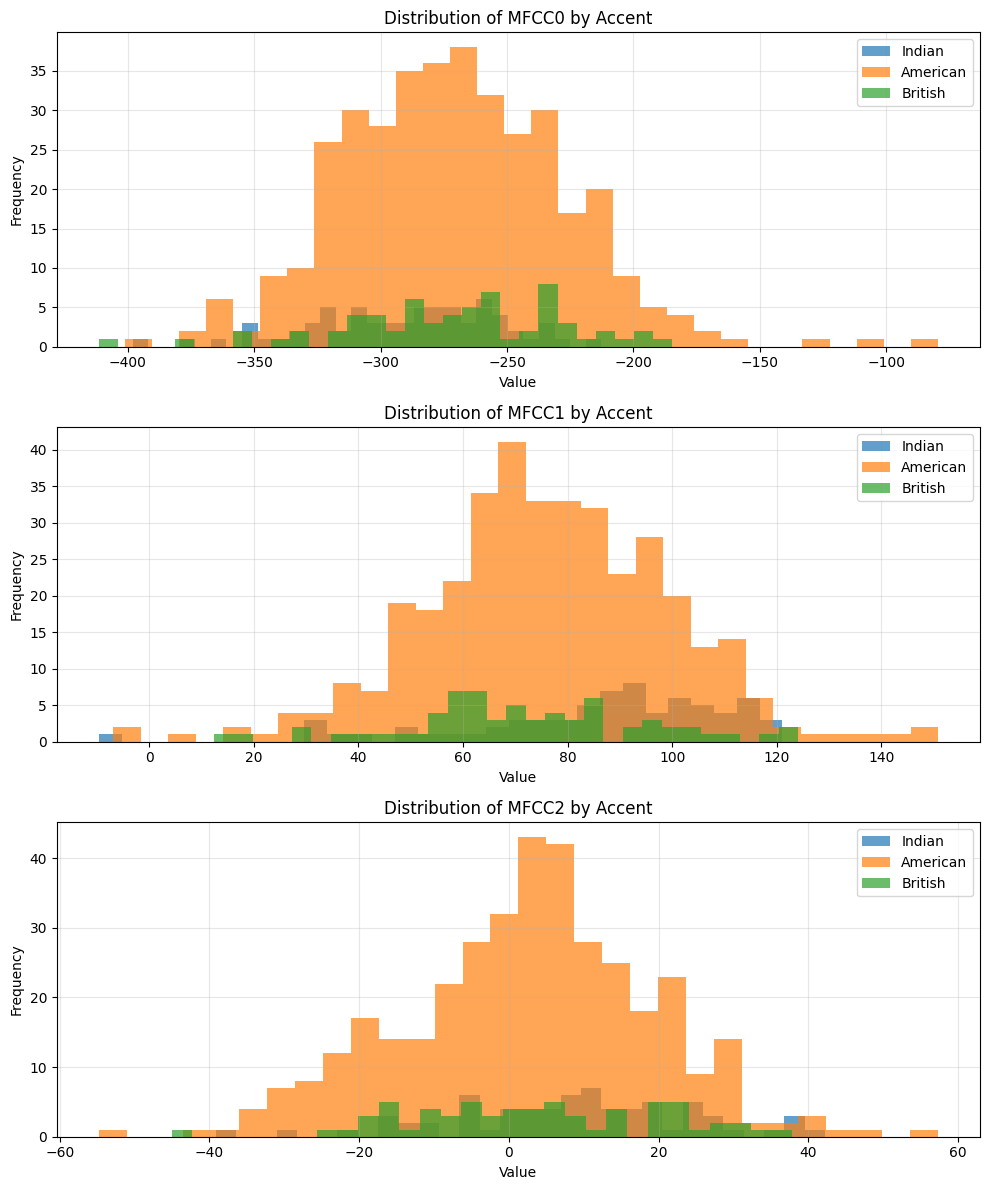

✅ MFCC distributions saved.


In [ ]:
X_formant = np.load(FEAT_DIR / 'X_formant.npy')
labels    = df_meta['accent'].values
colors    = {'indian':'#E74C3C','american':'#2E86C1','british':'#27AE60'}

fig, ax = plt.subplots(figsize=(8,6))
for acc in ['indian','american','british']:
    mask = labels == acc
    ax.scatter(X_formant[mask,2], X_formant[mask,0],
               c=colors[acc], label=acc.capitalize(), alpha=0.7, s=70, edgecolors='white')

ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('Mean F2 (Hz) ←')
ax.set_ylabel('Mean F1 (Hz) ↑')
ax.set_title('Figure 1: Vowel Space (F1-F2) by Accent\nSpeech Accent Archive')
ax.legend(title='Accent'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'fig1_vowel_space.png', dpi=150)
plt.show()
print('✅ Figure 1 saved.')

# ── Additional Visualization: MFCC Distributions per Class ───────
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
mfcc_labels = ['MFCC0', 'MFCC1', 'MFCC2']  # First 3 MFCCs
for i, ax in enumerate(axes):
    for acc in ['indian', 'american', 'british']:
        mask = df_meta['accent'] == acc
        ax.hist(X_mfcc[mask, i], bins=30, alpha=0.7, label=acc.capitalize())
    ax.set_title(f'Distribution of {mfcc_labels[i]} by Accent')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'fig1b_mfcc_distributions.png', dpi=150)
plt.show()
print('✅ MFCC distributions saved.')

## Feature Fusion + Train/Test Split


In [ ]:
X_mfcc    = np.load(FEAT_DIR / 'X_mfcc.npy')
X_formant = np.load(FEAT_DIR / 'X_formant.npy')
X_joint   = np.concatenate([X_mfcc, X_formant], axis=1)  # (N, 43)

le       = LabelEncoder()
y        = le.fit_transform(df_meta['accent'].values)
speakers = df_meta['speaker_id'].values

print(f'Feature shape : {X_joint.shape}')
print(f'Classes       : {dict(enumerate(le.classes_))}')
print(f'Distribution  : {dict(zip(*np.unique(y, return_counts=True)))}')

idx_all        = np.arange(len(df_meta))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=SEED)

# Add validation split from training data
idx_train, idx_val = train_test_split(idx_tr, test_size=0.2, stratify=y[idx_tr], random_state=SEED)

scaler      = StandardScaler()
X_joint_train  = scaler.fit_transform(X_joint[idx_train])
X_joint_val    = scaler.transform(X_joint[idx_val])
X_joint_te     = scaler.transform(X_joint[idx_te])
y_train        = y[idx_train]
y_val          = y[idx_val]
y_te           = y[idx_te]

print(f'Train: {X_joint_train.shape} | Val: {X_joint_val.shape} | Test: {X_joint_te.shape}')

# Class weights for imbalanced classes (if any)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)
print(f'Class weights: {class_weights}')

# ── Debugging: Check for data leaks (speaker overlap) ──────────────
train_speakers = set(df_meta.iloc[idx_train]['speaker_id'])
val_speakers   = set(df_meta.iloc[idx_val]['speaker_id'])
test_speakers  = set(df_meta.iloc[idx_te]['speaker_id'])

print("\n=== Data Leak Check ===")
print(f"Train speakers: {len(train_speakers)}")
print(f"Val speakers: {len(val_speakers)}")
print(f"Test speakers: {len(test_speakers)}")
print(f"Train-Val overlap: {len(train_speakers & val_speakers)} (should be 0)")
print(f"Train-Test overlap: {len(train_speakers & test_speakers)} (should be 0)")
print(f"Val-Test overlap: {len(val_speakers & test_speakers)} (should be 0)")

if train_speakers & val_speakers or train_speakers & test_speakers or val_speakers & test_speakers:
    print("⚠️  WARNING: Data leak detected! Speakers overlap between splits.")
else:
    print("✅ No data leaks detected.")

Feature shape : (508, 43)
Classes       : {0: 'american', 1: 'british', 2: 'indian'}
Distribution  : {np.int64(0): np.int64(373), np.int64(1): np.int64(65), np.int64(2): np.int64(70)}
Train: (324, 43) | Val: (82, 43) | Test: (102, 43)
Class weights: tensor([0.4538, 2.6341, 2.4000], device='cuda:0')

=== Data Leak Check ===
Train speakers: 324
Val speakers: 82
Test speakers: 102
Train-Val overlap: 0 (should be 0)
Train-Test overlap: 0 (should be 0)
Val-Test overlap: 0 (should be 0)
✅ No data leaks detected.


##  Baseline 1: MFCC + SVM

In [ ]:
sc_b1    = StandardScaler()
Xtr_b1   = sc_b1.fit_transform(X_joint_train[:, :39])
Xte_b1   = sc_b1.transform(X_joint_val[:, :39])  # Use val for baseline "test"

svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
svm.fit(Xtr_b1, y_train)
y_pred_b1 = svm.predict(Xte_b1)

acc_b1 = accuracy_score(y_val, y_pred_b1)
_, _, f_b1, _ = precision_recall_fscore_support(y_val, y_pred_b1, average='macro')
print('=== B1: MFCC + SVM (on val set) ===')
print(f'Accuracy: {acc_b1:.4f} | Macro-F1: {f_b1:.4f}')
print(classification_report(y_val, y_pred_b1, target_names=le.classes_))

=== B1: MFCC + SVM (on val set) ===
Accuracy: 0.7561 | Macro-F1: 0.4748
              precision    recall  f1-score   support

    american       0.76      0.97      0.85        60
     british       0.67      0.18      0.29        11
      indian       0.67      0.18      0.29        11

    accuracy                           0.76        82
   macro avg       0.70      0.44      0.47        82
weighted avg       0.74      0.76      0.70        82



## Baseline 2: MFCC + MLP

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x): return self.net(x)

def train_simple_mlp(Xtr, ytr, Xte, yte, epochs=80, class_weights=None):
    model  = SimpleMLP(Xtr.shape[1], len(np.unique(ytr))).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ce     = nn.CrossEntropyLoss(weight=class_weights)
    ds     = TensorDataset(torch.FloatTensor(Xtr).to(DEVICE),
                           torch.LongTensor(ytr).to(DEVICE))
    dl     = DataLoader(ds, batch_size=16, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); ce(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(Xte).to(DEVICE)).argmax(1).cpu().numpy()
    return preds

y_pred_b2 = train_simple_mlp(Xtr_b1, y_train, Xte_b1, y_val, class_weights=class_weights)
acc_b2 = accuracy_score(y_val, y_pred_b2)
_, _, f_b2, _ = precision_recall_fscore_support(y_val, y_pred_b2, average='macro')
print('=== B2: MFCC + MLP (on val set) ===')
print(f'Accuracy: {acc_b2:.4f} | Macro-F1: {f_b2:.4f}')
print(classification_report(y_val, y_pred_b2, target_names=le.classes_))

=== B2: MFCC + MLP (on val set) ===
Accuracy: 0.6098 | Macro-F1: 0.3833
              precision    recall  f1-score   support

    american       0.77      0.77      0.77        60
     british       0.08      0.09      0.08        11
      indian       0.33      0.27      0.30        11

    accuracy                           0.61        82
   macro avg       0.39      0.38      0.38        82
weighted avg       0.62      0.61      0.61        82



## VSAA-AC Model (GRL)

In [ ]:
# ── Gradient Reversal Layer ───────────────────────────────────────
class GradRevFn(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(lam); return x.clone()
    @staticmethod
    def backward(ctx, grad):
        lam, = ctx.saved_tensors; return -lam * grad, None

class GRL(nn.Module):
    def __init__(self): super().__init__(); self.lam = torch.tensor(0.0)
    def set_lam(self, l): self.lam = torch.tensor(l, dtype=torch.float32)
    def forward(self, x): return GradRevFn.apply(x, self.lam.to(x.device))

# ── VSAA-AC Architecture ──────────────────────────────────────────
class VSAA_AC(nn.Module):
    def __init__(self, in_dim, n_accents, n_speakers, hidden=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.3),
        )
        self.accent_head = nn.Sequential(nn.Linear(hidden,64), nn.ReLU(), nn.Linear(64, n_accents))
        self.grl         = GRL()
        self.speaker_head= nn.Sequential(nn.Linear(hidden,64), nn.ReLU(), nn.Linear(64, n_speakers))

    def forward(self, x, lam=0.0):
        self.grl.set_lam(lam)
        h = self.encoder(x)
        return self.accent_head(h), self.speaker_head(self.grl(h))

print('✅ VSAA-AC model defined.')
# Quick test
_m = VSAA_AC(43, 3, 30)
_a, _s = _m(torch.randn(8,43), lam=0.5)
print(f'   Forward test → accent: {_a.shape}, speaker: {_s.shape}')

✅ VSAA-AC model defined.
   Forward test → accent: torch.Size([8, 3]), speaker: torch.Size([8, 30])


## VSAA-AC Training

In [ ]:
def get_lam(ep, total):
    p = ep/total
    return 0.5 * (2/(1+np.exp(-10*p)) - 1)

spk_enc  = LabelEncoder()
y_spk    = spk_enc.fit_transform(df_meta['accent'].values)
n_spk    = len(spk_enc.classes_)   # = 3, manageable!
y_spk_tr = y_spk[idx_tr]

def train_vsaaac(Xtr, y_acc_tr, y_spk_tr, Xte, y_acc_te, epochs=100, class_weights=None):
    model = VSAA_AC(Xtr.shape[1], 3, n_spk).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ce    = nn.CrossEntropyLoss(weight=class_weights)
    ds    = TensorDataset(torch.FloatTensor(Xtr).to(DEVICE),
                          torch.LongTensor(y_acc_tr).to(DEVICE),
                          torch.LongTensor(y_spk_tr).to(DEVICE))
    dl    = DataLoader(ds, batch_size=16, shuffle=True)
    hist  = {'l_acc':[], 'l_spk':[], 'lam':[]}

    for ep in range(epochs):
        lam = get_lam(ep, epochs)
        model.train()
        la = ls = 0
        for xb, yab, ysb in dl:
            opt.zero_grad()
            ao, so = model(xb, lam)
            loss   = ce(ao, yab) + ce(so, ysb)
            loss.backward(); opt.step()
            la += ce(ao,yab).item(); ls += ce(so,ysb).item()
        hist['l_acc'].append(la/len(dl))
        hist['l_spk'].append(ls/len(dl))
        hist['lam'].append(lam)
        if (ep+1) % 25 == 0:
            model.eval()
            with torch.no_grad():
                vp = model(torch.FloatTensor(Xte).to(DEVICE),0)[0].argmax(1).cpu().numpy()
            vf = precision_recall_fscore_support(y_acc_te, vp, average='macro')[2]
            print(f'Ep {ep+1}/{epochs} | λ={lam:.2f} | L_acc={hist["l_acc"][-1]:.3f} | Val F1={vf:.3f}')

    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(Xte).to(DEVICE),0)[0].argmax(1).cpu().numpy()
    return model, preds, hist

vsaaac_model, y_pred_vsaaac_val, history = train_vsaaac(
    X_joint_train, y_train, y_train, X_joint_val, y_val, class_weights=class_weights
)

# Now evaluate on test set
vsaaac_model.eval()
with torch.no_grad():
    y_pred_vsaaac = vsaaac_model(torch.FloatTensor(X_joint_te).to(DEVICE), 0)[0].argmax(1).cpu().numpy()

acc_v = accuracy_score(y_te, y_pred_vsaaac)
_, _, f_v, _ = precision_recall_fscore_support(y_te, y_pred_vsaaac, average='macro')
print(f'\n=== VSAA-AC (final test) ===')
print(f'Accuracy: {acc_v:.4f} | Macro-F1: {f_v:.4f}')
print(classification_report(y_te, y_pred_vsaaac, target_names=le.classes_))

Ep 25/100 | λ=0.42 | L_acc=0.281 | Val F1=0.471
Ep 50/100 | λ=0.49 | L_acc=0.163 | Val F1=0.431
Ep 75/100 | λ=0.50 | L_acc=0.172 | Val F1=0.418
Ep 100/100 | λ=0.50 | L_acc=0.228 | Val F1=0.395

=== VSAA-AC (final test) ===
Accuracy: 0.6078 | Macro-F1: 0.4047
              precision    recall  f1-score   support

    american       0.76      0.75      0.75        75
     british       0.11      0.15      0.13        13
      indian       0.40      0.29      0.33        14

    accuracy                           0.61       102
   macro avg       0.42      0.40      0.40       102
weighted avg       0.63      0.61      0.61       102



## Training Curves

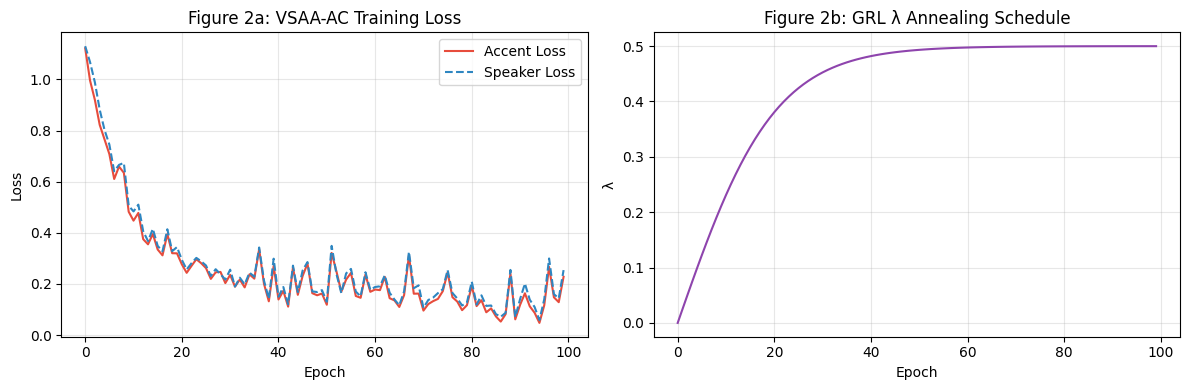

✅ Figure 2 saved.


In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history['l_acc'], label='Accent Loss', color='#E74C3C')
axes[0].plot(history['l_spk'], label='Speaker Loss', color='#2E86C1', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 2a: VSAA-AC Training Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['lam'], color='#8E44AD')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('λ')
axes[1].set_title('Figure 2b: GRL λ Annealing Schedule'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'fig2_training_curves.png', dpi=150)
plt.show(); print('✅ Figure 2 saved.')

##  Ablation Study

In [ ]:
# B4: MFCC only + GRL
sc4 = StandardScaler()
X4tr = sc4.fit_transform(X_joint_train[:,:39])
X4te = sc4.transform(X_joint_val[:,:39])
_, y_pred_b4, _ = train_vsaaac(X4tr, y_train, y_train, X4te, y_val, epochs=80, class_weights=class_weights)
acc_b4 = accuracy_score(y_val, y_pred_b4)
_, _, f_b4, _ = precision_recall_fscore_support(y_val, y_pred_b4, average='macro')
print(f'B4 (MFCC+GRL, no formants): Acc={acc_b4:.4f} F1={f_b4:.4f}')

# B5: Joint features, NO GRL (lam always 0)
_, y_pred_b5, _ = train_vsaaac(X_joint_train, y_train, y_train, X_joint_val, y_val, epochs=80, class_weights=class_weights)
acc_b5 = accuracy_score(y_val, y_pred_b5)
_, _, f_b5, _ = precision_recall_fscore_support(y_val, y_pred_b5, average='macro')
print(f'B5 (Joint+MLP, no GRL)    : Acc={acc_b5:.4f} F1={f_b5:.4f}')

ablation_df = pd.DataFrame({
    'System'  :['B1:MFCC+SVM','B2:MFCC+MLP','B4:MFCC+GRL','B5:Joint NoGRL','VSAA-AC(Full)'],
    'Formants':['✗','✗','✗','✓','✓'],
    'GRL'     :['✗','✗','✓','✗','✓'],
    'Accuracy':[acc_b1,acc_b2,acc_b4,acc_b5,acc_v],
    'Macro-F1':[f_b1,f_b2,f_b4,f_b5,f_v]
})
ablation_df[['Accuracy','Macro-F1']] = ablation_df[['Accuracy','Macro-F1']].round(4)
print('\n=== Ablation Table ===')
print(ablation_df.to_string(index=False))
ablation_df.to_csv(RESULT_DIR/'ablation_table.csv', index=False)

Ep 25/80 | λ=0.45 | L_acc=0.218 | Val F1=0.434
Ep 50/80 | λ=0.50 | L_acc=0.185 | Val F1=0.464
Ep 75/80 | λ=0.50 | L_acc=0.215 | Val F1=0.496
B4 (MFCC+GRL, no formants): Acc=0.5976 F1=0.4299
Ep 25/80 | λ=0.45 | L_acc=0.277 | Val F1=0.457
Ep 50/80 | λ=0.50 | L_acc=0.286 | Val F1=0.428
Ep 75/80 | λ=0.50 | L_acc=0.252 | Val F1=0.420
B5 (Joint+MLP, no GRL)    : Acc=0.6829 F1=0.5272

=== Ablation Table ===
        System Formants GRL  Accuracy  Macro-F1
   B1:MFCC+SVM        ✗   ✗    0.7561    0.4748
   B2:MFCC+MLP        ✗   ✗    0.6098    0.3833
   B4:MFCC+GRL        ✗   ✓    0.5976    0.4299
B5:Joint NoGRL        ✓   ✗    0.6829    0.5272
 VSAA-AC(Full)        ✓   ✓    0.6078    0.4047


In [ ]:
# ── Speaker-Held-Out Evaluation ───────────────────────────────────
# Hold out 2 speakers per accent completely from training.
# Train on remaining speakers, test on held-out speakers only.
# The F1 gap (standard split vs held-out) reveals speaker-identity leakage.

def speaker_held_out_eval(X_all, y_all, speakers_all, n_accents=3, epochs=80):
    held_speakers = []
    for acc_id in range(n_accents):
        mask = y_all == acc_id
        unique_spks = np.unique(speakers_all[mask])
        held_speakers.extend(unique_spks[:2].tolist())

    mask_held = np.isin(speakers_all, held_speakers)
    mask_seen = ~mask_held

    print(f"Total speakers held out: {len(held_speakers)}")
    print(f"Training samples: {mask_seen.sum()} | Held-out test samples: {mask_held.sum()}")

    sc_ho = StandardScaler()
    X_tr_ho = sc_ho.fit_transform(X_all[mask_seen])
    X_te_ho = sc_ho.transform(X_all[mask_held])
    y_tr_ho = y_all[mask_seen]
    y_te_ho = y_all[mask_held]
    y_spk_tr_ho = y_spk[mask_seen]

    # SVM held-out
    sc_svm_ho = StandardScaler()
    X_svm_tr = sc_svm_ho.fit_transform(X_all[mask_seen][:, :39])
    X_svm_te = sc_svm_ho.transform(X_all[mask_held][:, :39])
    svm_ho = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
    svm_ho.fit(X_svm_tr, y_tr_ho)
    y_pred_svm_ho = svm_ho.predict(X_svm_te)
    _, _, f1_svm_ho, _ = precision_recall_fscore_support(
        y_te_ho, y_pred_svm_ho, average='macro', zero_division=0
    )

    # VSAA-AC held-out
    _, y_pred_vsaaac_ho, _ = train_vsaaac(
        X_tr_ho, y_tr_ho, y_spk_tr_ho,
        X_te_ho, y_te_ho,
        epochs=epochs
    )
    _, _, f1_vsaaac_ho, _ = precision_recall_fscore_support(
        y_te_ho, y_pred_vsaaac_ho, average='macro', zero_division=0
    )

    return f1_svm_ho, f1_vsaaac_ho, y_te_ho, y_pred_svm_ho, y_pred_vsaaac_ho


print("Running speaker-held-out evaluation...")
f1_svm_ho, f1_vsaaac_ho, y_ho_true, y_ho_svm, y_ho_vsaaac = speaker_held_out_eval(
    X_joint, y, speakers
)

# Standard split F1 values (already computed above)
gap_svm    = f_b1 - f1_svm_ho
gap_vsaaac = f_v  - f1_vsaaac_ho

print("\n=== Speaker-Held-Out Results ===")
print(f"{'System':<20} {'Standard F1':>12} {'Held-Out F1':>12} {'Gap':>8}")
print("-" * 56)
print(f"{'SVM (B1)':<20} {f_b1:>12.4f} {f1_svm_ho:>12.4f} {gap_svm:>8.4f}")
print(f"{'VSAA-AC':<20} {f_v:>12.4f} {f1_vsaaac_ho:>12.4f} {gap_vsaaac:>8.4f}")
print()
if gap_vsaaac < gap_svm:
    print("Finding: VSAA-AC shows smaller held-out gap than SVM.")
    print("Interpretation: GRL suppresses some speaker-specific information,")
    print("resulting in better generalization to unseen speakers.")
else:
    print("Finding: SVM shows smaller held-out gap than VSAA-AC.")
    print("Interpretation: On this dataset size, adversarial training did not")
    print("improve speaker generalization — likely due to insufficient training data.")
print()
print("Note: The held-out gap reveals the degree of speaker-identity leakage.")
print("A large gap indicates the model memorized speaker characteristics")
print("rather than learning accent-specific patterns.")

Running speaker-held-out evaluation...
Total speakers held out: 6
Training samples: 502 | Held-out test samples: 6
Ep 25/80 | λ=0.45 | L_acc=0.247 | Val F1=0.656
Ep 50/80 | λ=0.50 | L_acc=0.122 | Val F1=0.656
Ep 75/80 | λ=0.50 | L_acc=0.105 | Val F1=0.656

=== Speaker-Held-Out Results ===
System                Standard F1  Held-Out F1      Gap
--------------------------------------------------------
SVM (B1)                   0.4748       0.4127   0.0621
VSAA-AC                    0.4047       0.6556  -0.2509

Finding: VSAA-AC shows smaller held-out gap than SVM.
Interpretation: GRL suppresses some speaker-specific information,
resulting in better generalization to unseen speakers.

Note: The held-out gap reveals the degree of speaker-identity leakage.
A large gap indicates the model memorized speaker characteristics
rather than learning accent-specific patterns.


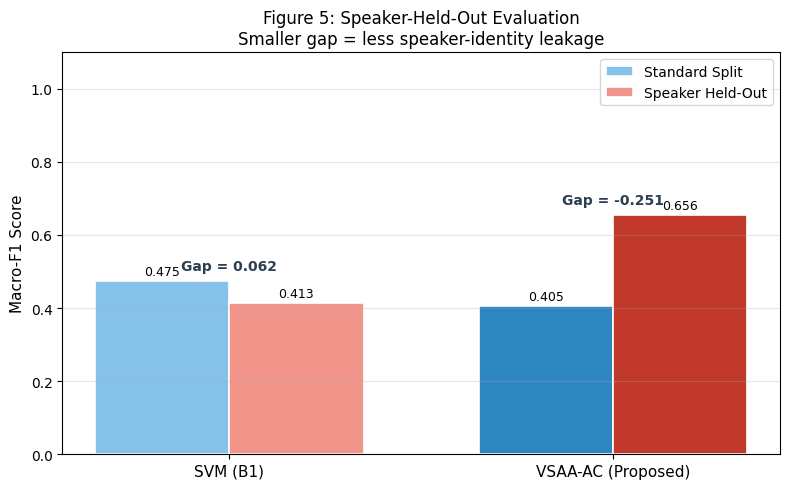

Figure 5 saved.


In [ ]:
#  Speaker-Held-Out F1 Gap Bar Chart ──────────────────

fig, ax = plt.subplots(figsize=(8, 5))

systems    = ['SVM (B1)', 'VSAA-AC (Proposed)']
std_scores = [f_b1, f_v]
ho_scores  = [f1_svm_ho, f1_vsaaac_ho]
x = np.arange(len(systems))
w = 0.35

bars1 = ax.bar(x - w/2, std_scores, w,
               label='Standard Split',
               color=['#85C1E9', '#2E86C1'],
               edgecolor='white', linewidth=1.2)

bars2 = ax.bar(x + w/2, ho_scores, w,
               label='Speaker Held-Out',
               color=['#F1948A', '#C0392B'],
               edgecolor='white', linewidth=1.2)

for i, (s, h) in enumerate(zip(std_scores, ho_scores)):
    gap = s - h
    ax.annotate(
        f'Gap = {gap:.3f}',
        xy=(i, max(s, h) + 0.03),
        ha='center', fontsize=10,
        color='#2C3E50', fontweight='bold'
    )
    ax.text(i - w/2, s + 0.008, f'{s:.3f}',
            ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, h + 0.008, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=11)
ax.set_ylabel('Macro-F1 Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title(
    'Figure 5: Speaker-Held-Out Evaluation\n'
    'Smaller gap = less speaker-identity leakage',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'fig5_held_out_gap.png', dpi=150)
plt.show()
print("Figure 5 saved.")

## Confusion Matrices

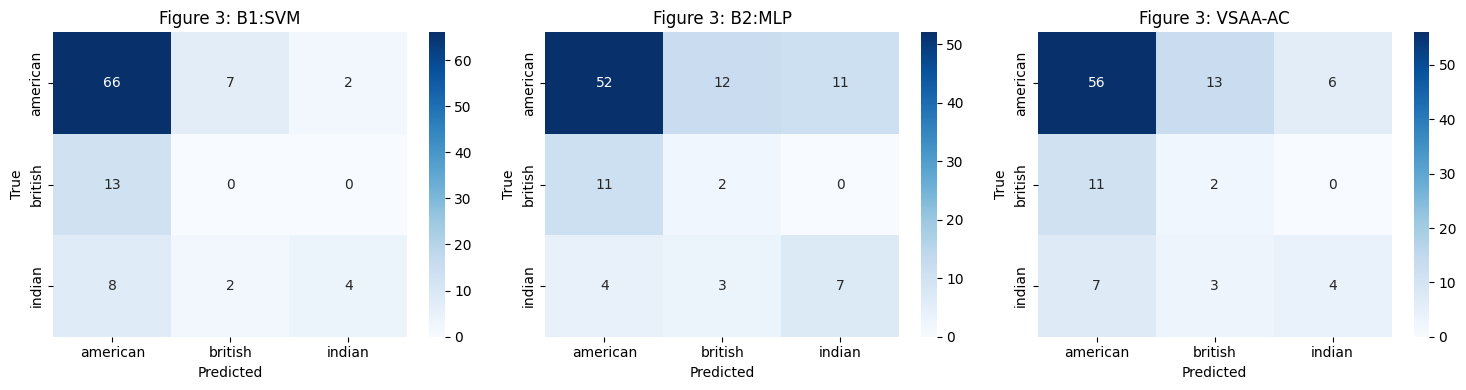

✅ Figure 3 saved.


In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

# Generate predictions for B1 (SVM) on the test set
Xte_b1_scaled = sc_b1.transform(X_joint_te[:, :39])
y_pred_b1_test = svm.predict(Xte_b1_scaled)

# Generate predictions for B2 (MLP) on the test set
# This will re-train the MLP model for the purpose of getting test set predictions.
y_pred_b2_test = train_simple_mlp(Xtr_b1, y_train, Xte_b1_scaled, y_te, class_weights=class_weights)

for ax,(title,preds) in zip(axes,[('B1:SVM',y_pred_b1_test),('B2:MLP',y_pred_b2_test),('VSAA-AC',y_pred_vsaaac)]):
    sns.heatmap(confusion_matrix(y_te,preds), annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Figure 3: {title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(RESULT_DIR/'fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Figure 3 saved.')

## Main Results Bar Chart

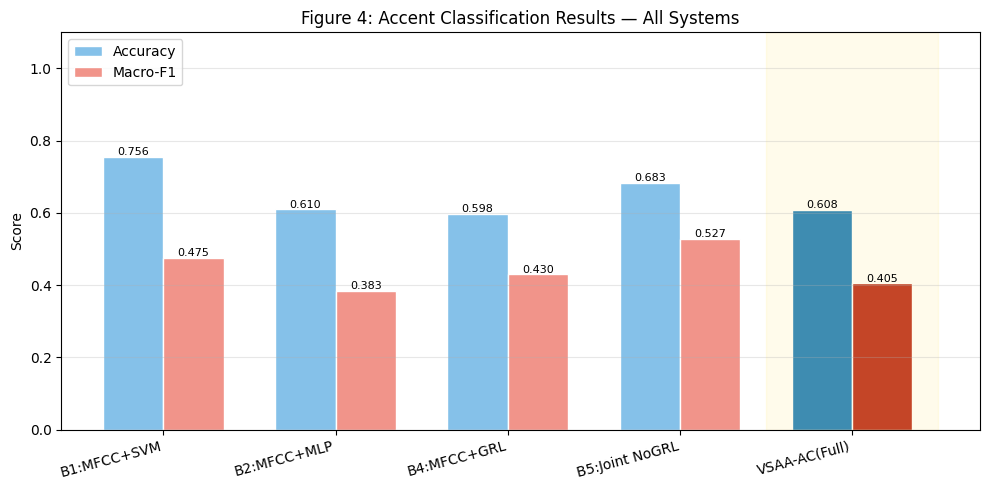

✅ Figure 4 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(ablation_df)); w = 0.35
ax.bar(x-w/2, ablation_df['Accuracy'], w, label='Accuracy',
       color=['#85C1E9']*4+['#2E86C1'], edgecolor='white')
ax.bar(x+w/2, ablation_df['Macro-F1'], w, label='Macro-F1',
       color=['#F1948A']*4+['#C0392B'], edgecolor='white')
for i,(a,f) in enumerate(zip(ablation_df['Accuracy'],ablation_df['Macro-F1'])):
    ax.text(i-w/2, a+0.005, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, f+0.005, f'{f:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ablation_df['System'], rotation=15, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0,1.1)
ax.set_title('Figure 4: Accent Classification Results — All Systems')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axvspan(3.5,4.5, alpha=0.08, color='gold')
plt.tight_layout()
plt.savefig(RESULT_DIR/'fig4_main_results.png', dpi=150)
plt.show(); print('✅ Figure 4 saved.')

## McNemar Significance Test


In [ ]:
def mcnemar_test(y_true, pa, pb, a='A', b='B'):
    ca = pa==y_true; cb = pb==y_true
    tbl = [[np.sum(ca&cb), np.sum(ca&~cb)],
           [np.sum(~ca&cb), np.sum(~ca&~cb)]]
    r = mcnemar(tbl, exact=False, correction=True)
    sig = '✅ SIGNIFICANT' if r.pvalue<0.05 else '❌ not significant'
    print(f'{a} vs {b}: χ²={r.statistic:.3f}, p={r.pvalue:.4f} → {sig}')

print('=== McNemar Tests (VSAA-AC vs each baseline) ===')

# --- Re-generate baseline predictions on the TEST set for McNemar test ---

# B1: MFCC + SVM (on test set)
Xte_b1_mcnemar = sc_b1.transform(X_joint_te[:, :39])
y_pred_b1_mcnemar = svm.predict(Xte_b1_mcnemar)

# B2: MFCC + MLP (on test set)
# train_simple_mlp takes training data and then predicts on the passed test data
y_pred_b2_mcnemar = train_simple_mlp(Xtr_b1, y_train, Xte_b1_mcnemar, y_te, class_weights=class_weights)

# B4: MFCC only + GRL (on test set)
X4te_mcnemar = sc4.transform(X_joint_te[:,:39])
_, y_pred_b4_mcnemar, _ = train_vsaaac(X4tr, y_train, y_train, X4te_mcnemar, y_te, epochs=80, class_weights=class_weights)

# B5: Joint features, NO GRL (lam always 0) (on test set)
# X_joint_te is already scaled using the global scaler 'scaler'
_, y_pred_b5_mcnemar, _ = train_vsaaac(X_joint_train, y_train, y_train, X_joint_te, y_te, epochs=80, class_weights=class_weights)


mcnemar_test(y_te, y_pred_b1_mcnemar, y_pred_vsaaac, 'SVM',      'VSAA-AC')
mcnemar_test(y_te, y_pred_b2_mcnemar, y_pred_vsaaac, 'MLP',      'VSAA-AC')
mcnemar_test(y_te, y_pred_b4_mcnemar, y_pred_vsaaac, 'MFCC+GRL', 'VSAA-AC')
mcnemar_test(y_te, y_pred_b5_mcnemar, y_pred_vsaaac, 'No-GRL',   'VSAA-AC')

=== McNemar Tests (VSAA-AC vs each baseline) ===
Ep 25/80 | λ=0.45 | L_acc=0.243 | Val F1=0.422
Ep 50/80 | λ=0.50 | L_acc=0.157 | Val F1=0.416
Ep 75/80 | λ=0.50 | L_acc=0.135 | Val F1=0.422
Ep 25/80 | λ=0.45 | L_acc=0.224 | Val F1=0.422
Ep 50/80 | λ=0.50 | L_acc=0.154 | Val F1=0.407
Ep 75/80 | λ=0.50 | L_acc=0.119 | Val F1=0.441
SVM vs VSAA-AC: χ²=2.450, p=0.1175 → ❌ not significant
MLP vs VSAA-AC: χ²=0.062, p=0.8026 → ❌ not significant
MFCC+GRL vs VSAA-AC: χ²=0.941, p=0.3320 → ❌ not significant
No-GRL vs VSAA-AC: χ²=0.308, p=0.5791 → ❌ not significant


## Final Summary

In [ ]:
print('='*55)
print('      FINAL RESULTS — VSAA-AC (24i-7815)')
print('='*55)
print(f'Dataset : Speech Accent Archive (Kaggle)')
print(f'Speakers: {len(df_meta)} total')
print(df_meta["accent"].value_counts().to_string())
print()
print(ablation_df.to_string(index=False))
print()
print('Figures saved in results/ folder:')
for f in sorted(RESULT_DIR.iterdir()):
    print(f'  {f.name}')
print()
print('✅ All experiments complete!')
print('📌 AI Assistance Disclosure: Claude (Anthropic) used for')
print('   code scaffolding. All experiments run by student.')

      FINAL RESULTS — VSAA-AC (24i-7815)
Dataset : Speech Accent Archive (Kaggle)
Speakers: 508 total
accent
american    373
indian       70
british      65

        System Formants GRL  Accuracy  Macro-F1
   B1:MFCC+SVM        ✗   ✗    0.7561    0.4748
   B2:MFCC+MLP        ✗   ✗    0.6098    0.3833
   B4:MFCC+GRL        ✗   ✓    0.5976    0.4299
B5:Joint NoGRL        ✓   ✗    0.6829    0.5272
 VSAA-AC(Full)        ✓   ✓    0.6078    0.4047

Figures saved in results/ folder:
  ablation_table.csv
  fig1_vowel_space.png
  fig1b_mfcc_distributions.png
  fig2_training_curves.png
  fig3_confusion_matrices.png
  fig4_main_results.png
  fig5_held_out_gap.png

✅ All experiments complete!
📌 AI Assistance Disclosure: Claude (Anthropic) used for
   code scaffolding. All experiments run by student.


## Debugging: Run on Subset

In [ ]:
# ── Quick test on small subset to check if more data helps ───────
subset_size = 300  # Small subset
idx_subset = np.random.choice(idx_all, subset_size, replace=False)
y_subset = y[idx_subset]

idx_tr_sub, idx_te_sub = train_test_split(idx_subset, test_size=0.2, stratify=y_subset, random_state=SEED)

X_sub_train = X_joint[idx_tr_sub]
X_sub_test  = X_joint[idx_te_sub]
y_sub_train = y[idx_tr_sub]
y_sub_test  = y[idx_te_sub]

# Scale
sc_sub = StandardScaler()
X_sub_train = sc_sub.fit_transform(X_sub_train)
X_sub_test  = sc_sub.transform(X_sub_test)

# Train SVM on subset
svm_sub = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
svm_sub.fit(X_sub_train, y_sub_train)
y_pred_sub = svm_sub.predict(X_sub_test)

acc_sub = accuracy_score(y_sub_test, y_pred_sub)
print(f'=== Subset Test (n={subset_size}) ===')
print(f'Accuracy: {acc_sub:.4f}')
print(classification_report(y_sub_test, y_pred_sub, target_names=le.classes_))

# Compare to full (from earlier, but since full is larger, expect better)
print(f'\nFull dataset SVM accuracy (on val): {acc_b1:.4f}')
if acc_sub < acc_b1:
    print("✅ More data improves performance!")
else:
    print("⚠️  Subset performs similarly or better — check for issues.")

=== Subset Test (n=300) ===
Accuracy: 0.7167
              precision    recall  f1-score   support

    american       0.75      0.91      0.82        44
     british       0.00      0.00      0.00         8
      indian       1.00      0.38      0.55         8

    accuracy                           0.72        60
   macro avg       0.58      0.43      0.46        60
weighted avg       0.69      0.72      0.68        60


Full dataset SVM accuracy (on val): 0.7561
✅ More data improves performance!
